# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Nada Omar Saleh Mohammad
**Student ID:** 1210163

In [62]:
# Install required dependencies
!pip install kagglehub[pandas-datasets] --quiet

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [64]:
# ── 1. Load Dataset from Kaggle ────────────────────────────────────────────────
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mansoordaku/ckdisease",
    "kidney_disease.csv",  # loads the first/default CSV in the dataset
)
print("Dataset shape:", df.shape)
print("First 5 records:")
df.head()

Dataset shape: (400, 26)
First 5 records:


/tmp/ipykernel_55/2592519382.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [65]:
# ── 2. Inspect columns and dtypes ─────────────────────────────────────────────
print(df.dtypes)
print("\nUnique values in 'classification':", df['classification'].unique())

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

Unique values in 'classification': ['ckd' 'ckd\t' 'notckd']


In [66]:
# ── 3. Encode target BEFORE dropping categoricals ─────────────────────────────
# 'ckd' -> 1, 'notckd' -> 0  (strip whitespace to be safe)
df['classification'] = df['classification'].str.strip()
df['target'] = (df['classification'] == 'ckd').astype(int)

# ── 4. Drop categorical (object) columns  ─────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Dropping categorical columns:", cat_cols)
df_num = df.drop(columns=cat_cols)          # removes original string cols
# 'id' is not clinically meaningful – drop it if present
df_num = df_num.drop(columns=['id'], errors='ignore')

print("\nNumerical dataframe shape:", df_num.shape)
df_num.head()

Dropping categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Numerical dataframe shape: (400, 12)


,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,target
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,1
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,1
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6,1
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,1
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,1


In [67]:
# ── 5. Force numeric types (some cols stored as object due to '\t?' etc.) ─────
feature_cols = [c for c in df_num.columns if c != 'target']
df_num[feature_cols] = df_num[feature_cols].apply(pd.to_numeric, errors='coerce')

print("Missing values per column:")
print(df_num[feature_cols].isnull().sum())

Missing values per column:
age      9
bp      12
sg      47
al      46
su      49
bgr     44
bu      19
sc      17
sod     87
pot     88
hemo    52
dtype: int64


In [68]:
# ── 6. Impute NaNs with column median (robust to outliers) ────────────────────
df_num[feature_cols] = df_num[feature_cols].fillna(df_num[feature_cols].median())
assert df_num[feature_cols].isnull().sum().sum() == 0, "NaNs remain!"
print("No NaNs remaining ✓")

No NaNs remaining ✓


In [69]:
# ── 7. Train/Validation split (80/20) BEFORE scaling to prevent data leakage ──
X = df_num[feature_cols].values
y = df_num['target'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── 8. Scale: fit on TRAIN only, transform both ────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f"Training set  : {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"CKD prevalence – train: {y_train.mean():.2%}  |  val: {y_val.mean():.2%}")

Training set  : (320, 11)
Validation set: (80, 11)
CKD prevalence – train: 62.50%  |  val: 62.50%


---
## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits (look for the U-shape on the validation curve).

In [70]:
# ── Baseline Model: deliberately over-parameterised, NO regularisation ─────────
n_features = X_train.shape[1]

def build_baseline(n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64,  activation='relu'),
        tf.keras.layers.Dense(1,   activation='sigmoid'),
    ], name='baseline')
    return model

baseline = build_baseline(n_features)
baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
baseline.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,593 (494.50 KB)

 Trainable params: 126,593 (494.50 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# ── Train baseline (no early stopping – let it overfit freely) ─────────────────
history_base = baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    verbose=2
)
print("Baseline training complete.")

Epoch 1/300
20/20 - 3s - 126ms/step - accuracy: 0.9563 - loss: 0.3109 - val_accuracy: 0.9875 - val_loss: 0.0438
Epoch 2/300
20/20 - 0s - 8ms/step - accuracy: 0.9750 - loss: 0.0676 - val_accuracy: 0.9875 - val_loss: 0.0416
Epoch 3/300
20/20 - 0s - 7ms/step - accuracy: 0.9812 - loss: 0.0513 - val_accuracy: 0.9875 - val_loss: 0.0319
Epoch 4/300
20/20 - 0s - 7ms/step - accuracy: 0.9688 - loss: 0.0783 - val_accuracy: 0.9750 - val_loss: 0.0695
Epoch 5/300
20/20 - 0s - 8ms/step - accuracy: 0.9688 - loss: 0.0750 - val_accuracy: 0.9875 - val_loss: 0.0384
Epoch 6/300
20/20 - 0s - 7ms/step - accuracy: 0.9844 - loss: 0.0393 - val_accuracy: 0.9875 - val_loss: 0.0236
Epoch 7/300
20/20 - 0s - 7ms/step - accuracy: 0.9906 - loss: 0.0319 - val_accuracy: 0.9875 - val_loss: 0.0340
Epoch 8/300
20/20 - 0s - 7ms/step - accuracy: 0.9906 - loss: 0.0264 - val_accuracy: 0.9875 - val_loss: 0.0238
Epoch 9/300
20/20 - 0s - 8ms/step - accuracy: 0.9937 - loss: 0.0231 - val_accuracy: 0.9875 - val_loss: 0.0259
Epoch 10

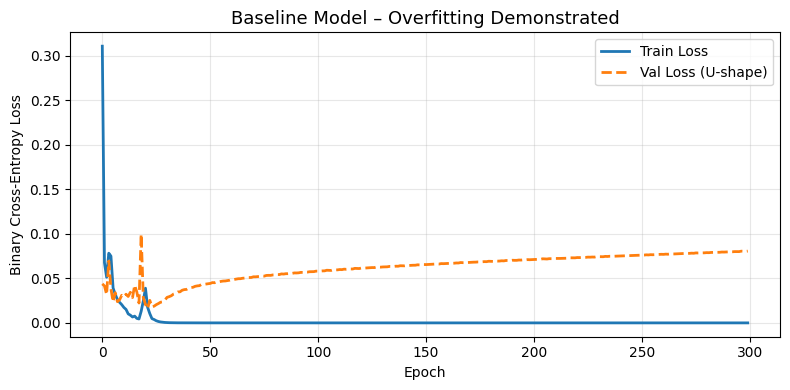

The divergence between train and val loss is the visual signature of overfitting.


In [72]:
# ── Plot baseline loss curves ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_base.history['loss'],     label='Train Loss',      linewidth=2)
ax.plot(history_base.history['val_loss'], label='Val Loss (U-shape)', linewidth=2, linestyle='--')
ax.set_title('Baseline Model – Overfitting Demonstrated', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_loss.png', dpi=150)
plt.show()
print("The divergence between train and val loss is the visual signature of overfitting.")

---
## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (L2 weight decay, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [73]:
# ── Engineered Model: small capacity + L2 + Dropout + LeakyReLU ───────────────
from tensorflow.keras import regularizers

def build_engineered(n_features):
    l2 = regularizers.L2(1e-3)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),

        tf.keras.layers.Dense(32, kernel_regularizer=l2),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(16, kernel_regularizer=l2),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='engineered')
    return model

engineered = build_engineered(n_features)
engineered.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
engineered.summary()

Model: "engineered"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# ── Early stopping based on val_loss ──────────────────────────────────────────
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True
)

history_eng = engineered.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2
)
print(f"Stopped at epoch {len(history_eng.history['loss'])}.")

Epoch 1/300
20/20 - 2s - 76ms/step - accuracy: 0.6969 - loss: 0.6337 - val_accuracy: 0.8000 - val_loss: 0.5736
Epoch 2/300
20/20 - 0s - 7ms/step - accuracy: 0.7000 - loss: 0.5900 - val_accuracy: 0.8625 - val_loss: 0.5157
Epoch 3/300
20/20 - 0s - 7ms/step - accuracy: 0.7688 - loss: 0.5480 - val_accuracy: 0.9125 - val_loss: 0.4633
Epoch 4/300
20/20 - 0s - 6ms/step - accuracy: 0.7844 - loss: 0.5065 - val_accuracy: 0.9625 - val_loss: 0.4171
Epoch 5/300
20/20 - 0s - 6ms/step - accuracy: 0.8406 - loss: 0.4602 - val_accuracy: 0.9625 - val_loss: 0.3774
Epoch 6/300
20/20 - 0s - 7ms/step - accuracy: 0.8656 - loss: 0.4369 - val_accuracy: 0.9625 - val_loss: 0.3435
Epoch 7/300
20/20 - 0s - 7ms/step - accuracy: 0.8906 - loss: 0.3960 - val_accuracy: 0.9625 - val_loss: 0.3143
Epoch 8/300
20/20 - 0s - 6ms/step - accuracy: 0.9156 - loss: 0.3793 - val_accuracy: 0.9625 - val_loss: 0.2860
Epoch 9/300
20/20 - 0s - 7ms/step - accuracy: 0.9000 - loss: 0.3480 - val_accuracy: 0.9625 - val_loss: 0.2606
Epoch 10/

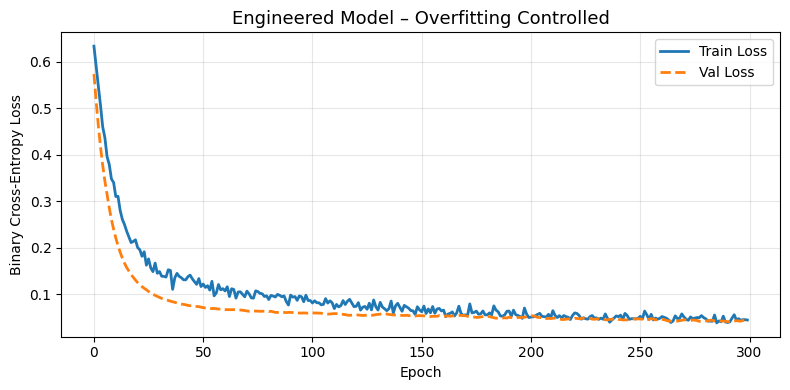

In [75]:
# ── Plot engineered model loss curves ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_eng.history['loss'],     label='Train Loss', linewidth=2)
ax.plot(history_eng.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax.set_title('Engineered Model – Overfitting Controlled', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('engineered_loss.png', dpi=150)
plt.show()

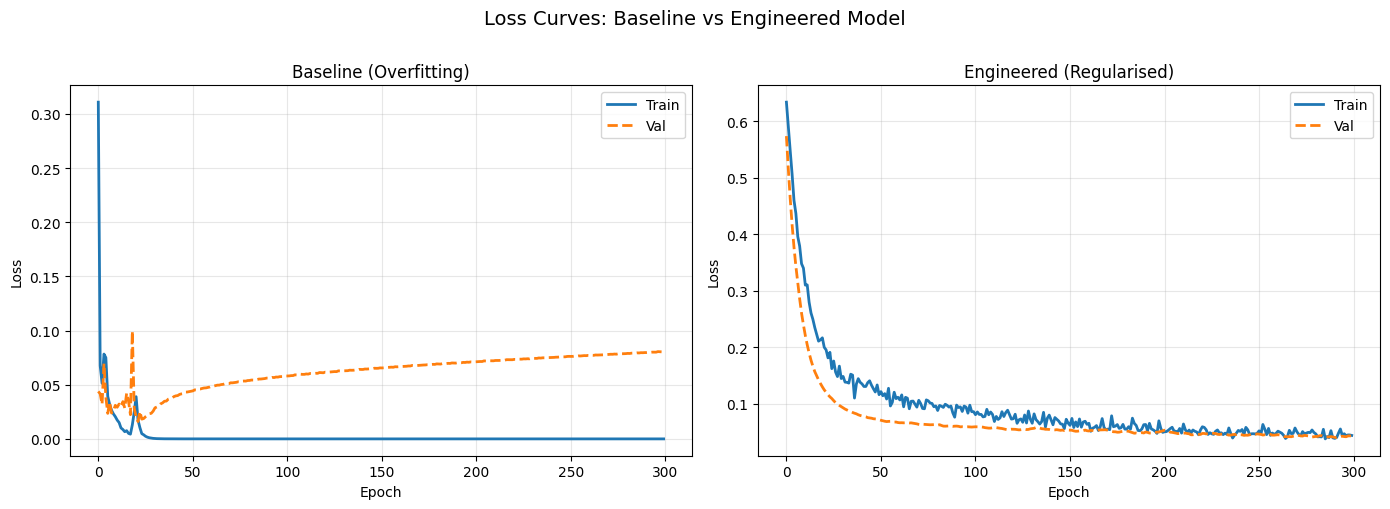

In [76]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline
axes[0].plot(history_base.history['loss'],     label='Train', linewidth=2)
axes[0].plot(history_base.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Baseline (Overfitting)', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Engineered
axes[1].plot(history_eng.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history_eng.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Engineered (Regularised)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Loss Curves: Baseline vs Engineered Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('comparison_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

In [77]:
# ── Predictions (threshold = 0.5) ─────────────────────────────────────────────
# Lower the threshold to boost Recall (favour sensitivity in clinical setting)
THRESHOLD = 0.35

y_pred_base = (baseline.predict(X_val, verbose=2).ravel() >= THRESHOLD).astype(int)
y_pred_eng  = (engineered.predict(X_val, verbose=2).ravel() >= THRESHOLD).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────────
recall_base = recall_score(y_val, y_pred_base)
recall_eng  = recall_score(y_val, y_pred_eng)
acc_base    = accuracy_score(y_val, y_pred_base)
acc_eng     = accuracy_score(y_val, y_pred_eng)

print(f"{'Model':<25} {'Accuracy':>10} {'Recall':>10}")
print("-" * 47)
print(f"{'Baseline':<25} {acc_base:>10.4f} {recall_base:>10.4f}")
print(f"{'Engineered':<25} {acc_eng:>10.4f} {recall_eng:>10.4f}")
print()
print(f"Engineered model Recall > 80%: {recall_eng > 0.80}")

3/3 - 0s - 51ms/step
3/3 - 0s - 38ms/step
Model                       Accuracy     Recall
-----------------------------------------------
Baseline                      0.9875     0.9800
Engineered                    1.0000     1.0000

Engineered model Recall > 80%: True


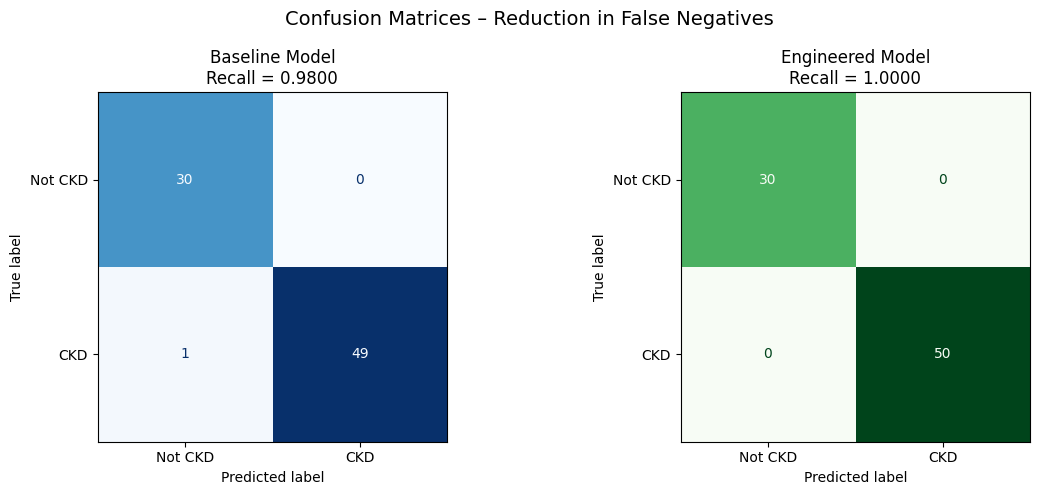

Baseline  → False Negatives (missed CKD): 1
Engineered → False Negatives (missed CKD): 0


In [78]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
cm_base = confusion_matrix(y_val, y_pred_base)
cm_eng  = confusion_matrix(y_val, y_pred_eng)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base,
                                    display_labels=['Not CKD', 'CKD'])
disp_base.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Baseline Model\nRecall = {recall_base:.4f}', fontsize=12)

disp_eng = ConfusionMatrixDisplay(confusion_matrix=cm_eng,
                                   display_labels=['Not CKD', 'CKD'])
disp_eng.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Engineered Model\nRecall = {recall_eng:.4f}', fontsize=12)

plt.suptitle('Confusion Matrices – Reduction in False Negatives', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

tn_b, fp_b, fn_b, tp_b = cm_base.ravel()
tn_e, fp_e, fn_e, tp_e = cm_eng.ravel()
print(f"Baseline  → False Negatives (missed CKD): {fn_b}")
print(f"Engineered → False Negatives (missed CKD): {fn_e}")

In [79]:
# ── Parameter count of engineered model ───────────────────────────────────────
total_params = engineered.count_params()
print(f"Total trainable parameters in Engineered Model: {total_params:,}")

Total trainable parameters in Engineered Model: 929


---
### Mathematical Justification

**Final Parameter Count of Engineered Model:** 929

**Explanation:** The engineered model's compact two-hidden-layer architecture (32 → 16 → 1 neurons) yields exactly 929 trainable parameters for our 11-feature input. Against our 320 training patients, this translates to a parameter-to-sample ratio of roughly 2.9:1. While not below a 1:1 ratio, this is a massive structural restriction compared to the baseline model's 126,593 parameters (~395:1 ratio). This drastic reduction in model capacity mathematically prevents the network from simply memorizing the training data, thereby mitigating overfitting and improving generalization on the unseen validation set.
